In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mennaemadalseady","key":"7f818e1c1a964300a244dda6ff82b1aa"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
#!/bin/bash
!kaggle datasets download mohitsingh1804/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:07<00:00, 119MB/s]



In [5]:
!rm -rf /content/plantvillage
!unzip -q plantvillage.zip -d /content/plantvillage

In [6]:
import os

base_dir = "/content/plantvillage/PlantVillage"

print(os.listdir(base_dir))

['val', 'train']


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [8]:
import tensorflow as tf
import os

base_dir = "/content/plantvillage/plantvillage"

train_dir = os.path.join('/content/plantvillage/PlantVillage/train')
val_dir = os.path.join('/content/plantvillage/PlantVillage/val')

img_size = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tom

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [10]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [11]:
from tensorflow.keras import models

num_classes = len(class_names)

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,134 (1.63 MB)

 Trainable params: 427,174 (1.63 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.5463 - loss: 1.7284 - val_accuracy: 0.4912 - val_loss: 1.9191 - learning_rate: 1.0000e-04
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 74s 54ms/step - accuracy: 0.7168 - loss: 0.9948 - val_accuracy: 0.5458 - val_loss: 1.7484 - learning_rate: 1.0000e-04
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.7905 - loss: 0.7111 - val_accuracy: 0.6744 - val_loss: 1.1260 - learning_rate: 1.0000e-04
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step - accuracy: 0.8373 - loss: 0.5450 - val_accuracy: 0.6517 - val_loss: 1.3094 - learning_rate: 1.0000e-04
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 76s 56ms/step - accuracy: 0.8701 - loss: 0.4373 - val_accuracy: 0.7852 - val_loss: 0.7067 - learning_rate: 1.0000e-04
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 76s 56ms/step - accuracy: 0.8906 - loss: 0.3694 - val_accuracy: 0.7825 - val_loss: 0.7650 - learning_rate: 1.0000e-04
Epoch 7/20
1358/1358 ━━━━━━━━━━━━━━━━━━━

In [15]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8827 - loss: 0.3920
Validation Loss: 0.3919675052165985
Validation Accuracy: 0.8826995491981506


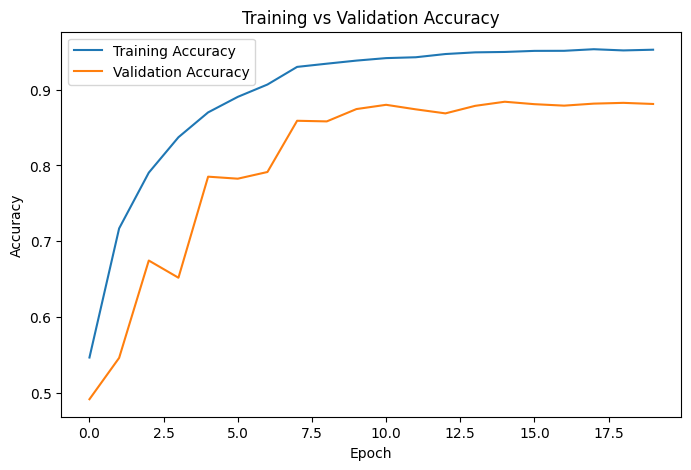

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

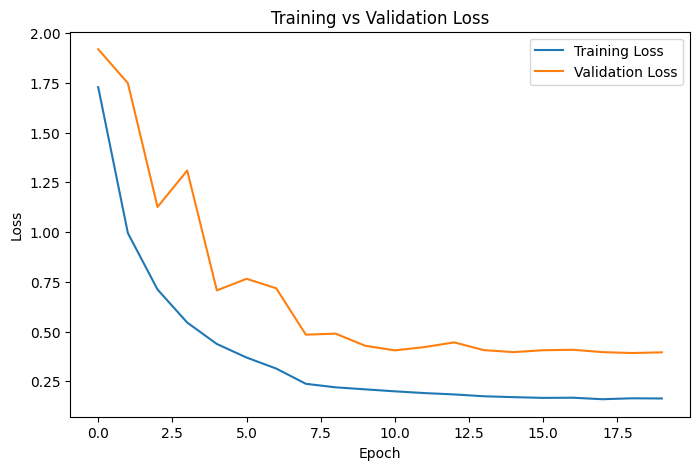

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [18]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.79      0.85       126
                                 Apple___Black_rot       0.58      0.99      0.74       125
                          Apple___Cedar_apple_rust       1.00      0.75      0.85        55
                                   Apple___healthy       0.87      0.80      0.83       329
                               Blueberry___healthy       0.92      0.98      0.95       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.76      0.86       210
                 Cherry_(including_sour)___healthy       0.85      0.98      0.91       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.65      0.93      0.77       103
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       239
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.75      0.

#MobileNetV2


In [51]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Number of classes: 38


In [52]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [53]:
model_mobilenet = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

model_mobilenet.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [54]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [55]:
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 114s 79ms/step - accuracy: 0.5387 - loss: 1.7683 - val_accuracy: 0.8248 - val_loss: 0.7674 - learning_rate: 1.0000e-04
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 139s 78ms/step - accuracy: 0.7521 - loss: 0.8757 - val_accuracy: 0.8803 - val_loss: 0.4795 - learning_rate: 1.0000e-04
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.8075 - loss: 0.6547 - val_accuracy: 0.8969 - val_loss: 0.3792 - learning_rate: 1.0000e-04
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.8337 - loss: 0.5590 - val_accuracy: 0.9084 - val_loss: 0.3226 - learning_rate: 1.0000e-04
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.8513 - loss: 0.4861 - val_accuracy: 0.9177 - val_loss: 0.2868 - learning_rate: 1.0000e-04
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.8664 - loss: 0.4410 - val_accuracy: 0.9239 - val_loss: 0.2630 - learning_rate: 1.0000e-04
Epoch 7/20
1358/1358 ━━━━━━━━━━━━━

In [57]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [60]:
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 96ms/step - accuracy: 0.8351 - loss: 0.5422 - val_accuracy: 0.9361 - val_loss: 0.1964
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 96ms/step - accuracy: 0.8971 - loss: 0.3205 - val_accuracy: 0.9441 - val_loss: 0.1682
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 96ms/step - accuracy: 0.9148 - loss: 0.2594 - val_accuracy: 0.9539 - val_loss: 0.1433
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 131s 96ms/step - accuracy: 0.9239 - loss: 0.2343 - val_accuracy: 0.9584 - val_loss: 0.1260
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 133s 98ms/step - accuracy: 0.9308 - loss: 0.2131 - val_accuracy: 0.9610 - val_loss: 0.1189
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 131s 96ms/step - accuracy: 0.9365 - loss: 0.1923 - val_accuracy: 0.9659 - val_loss: 0.1058
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 130s 96ms/step - accuracy: 0.9425 - loss: 0.1789 - val_accuracy: 0.9669 - val_loss: 0.1017
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 143s 96ms/step - accuracy: 

In [64]:
loss, accuracy = model_mobilenet.evaluate(val_ds)

print("MobileNetV2 Validation Loss:", loss)
print("MobileNetV2 Validation Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9717 - loss: 0.0905
MobileNetV2 Validation Loss: 0.09052670001983643
MobileNetV2 Validation Accuracy: 0.9717337489128113


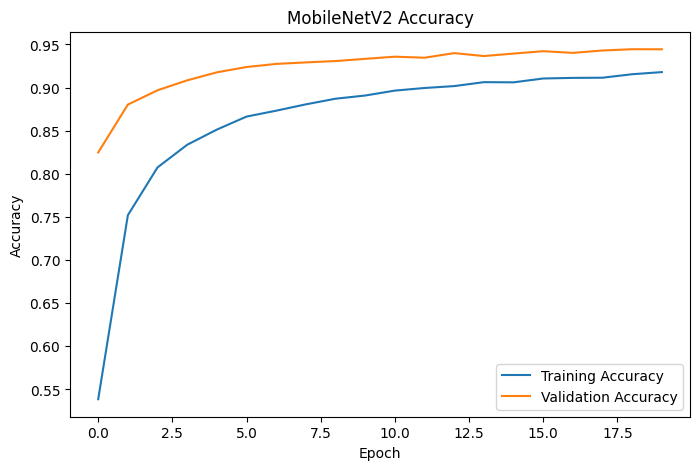

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_mobilenet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_mobilenet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.legend()
plt.show()

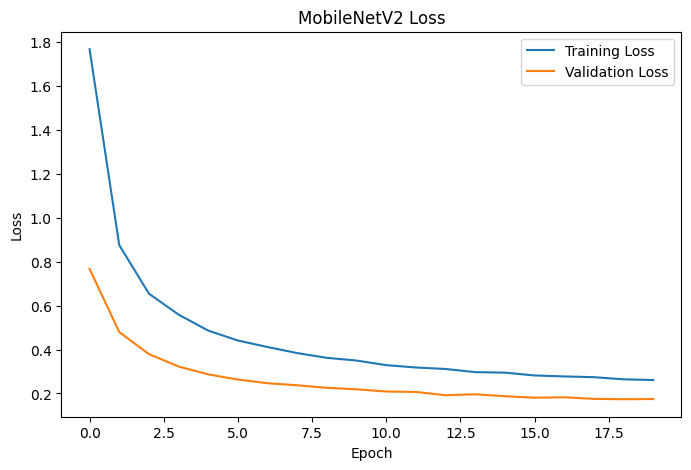

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_mobilenet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_mobilenet.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Loss")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_mobilenet.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

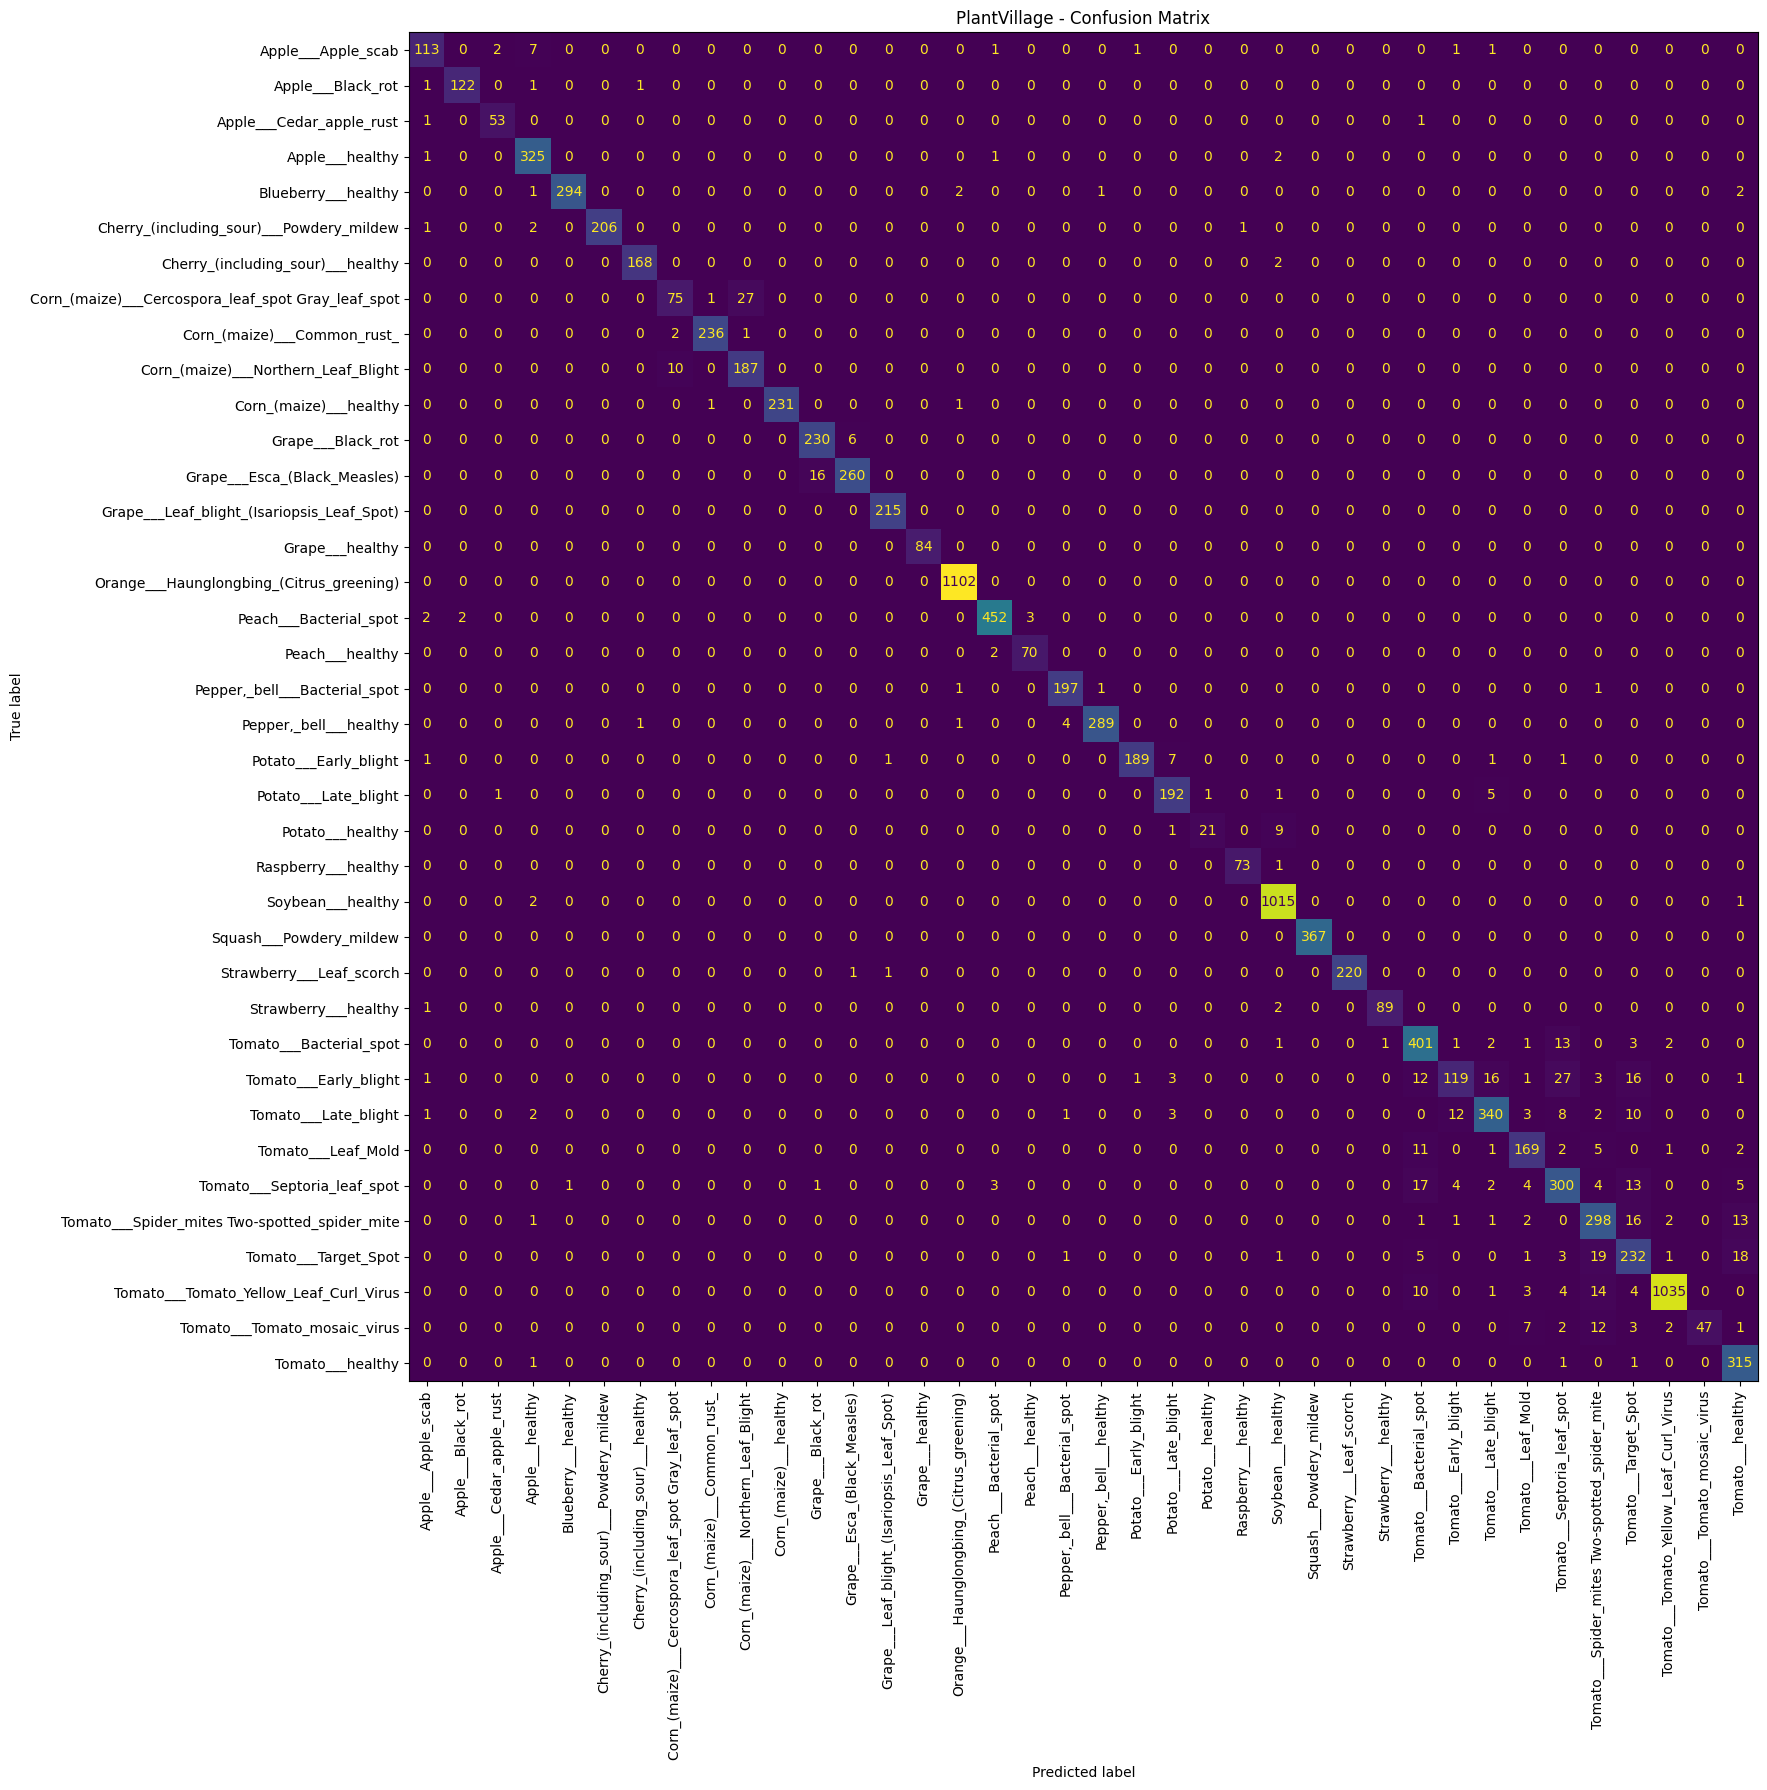

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("PlantVillage - Confusion Matrix")
plt.tight_layout()
plt.show()

In [35]:
model_mobilenet.save("/content/plantvillage_mobilenetv2.keras")

print("Model saved successfully!")

Model saved successfully!


## GUI


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# Prediction function
def predict_disease(image):
    if image is None:
        return "Please upload an image", {}

    # Resize image
    image = image.resize((224, 224))

    # Convert to numpy
    img_array = np.array(image)

    # Make sure image has 3 channels
    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    predictions = model_mobilenet.predict(img_array, verbose=0)[0]

    # Top 3 predictions
    top_indices = np.argsort(predictions)[-3:][::-1]

    top_results = {
        class_names[i]: float(predictions[i])
        for i in top_indices
    }

    # Best prediction
    best_index = top_indices[0]
    best_class = class_names[best_index]
    confidence = predictions[best_index] * 100

    result = f"{best_class}\nConfidence: {confidence:.2f}%"

    return result, top_results


# Create GUI
demo = gr.Interface(
    fn=predict_disease,

    inputs=gr.Image(
        type="pil",
        label="Upload Plant / Leaf Image"
    ),

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),
        gr.Label(
            label="Top 3 Predictions"
        )
    ],

    title="🌱 Plant Disease Detection",

    description=(
        "Upload an image of a plant leaf and "
        "the MobileNetV2 model will predict the disease."
    ),

    examples=None
)

demo.launch(share=True)